In [1]:
import numpy as np

class Sigmoid:
    def __init__(self):
        self.params = [] 

    def forward(self, x):
        return 1 / (1 + np.exp(-x))

class Affine:
    def __init__(self, W, b):
        self.params = [W, b]

    def forward(self, x):
        W, b = self.params
        out = np.dot(x, W) + b
        return out

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size
        W1 = np.random.randn(I, H)
        b1 = np.random.randn(H)
        W2 = np.random.randn(H, O)
        b2 = np.random.randn(O)

        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]

        self.params = []
        for layer in self.layers:
            self.params += layer.params

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

In [2]:
x = np.random.rand(10, 2)  # Example input
model = TwoLayerNet(input_size=2, hidden_size=4, output_size=3)
s = model.predict(x)
s

array([[ 1.67999453,  0.18066303, -2.40130617],
       [ 1.41812539,  0.40653778, -2.0767798 ],
       [ 1.61998834,  0.21628572, -2.33250848],
       [ 1.62912013,  0.13800363, -2.3150579 ],
       [ 1.64062364,  0.20641702, -2.35548176],
       [ 1.49058182,  0.33027135, -2.18312468],
       [ 1.55392831,  0.2016904 , -2.23826028],
       [ 1.47833346,  0.31877274, -2.17932838],
       [ 1.56798008,  0.289246  , -2.22937749],
       [ 1.50568524,  0.32459861, -2.1926538 ]])

(300, 2)
(300, 3)


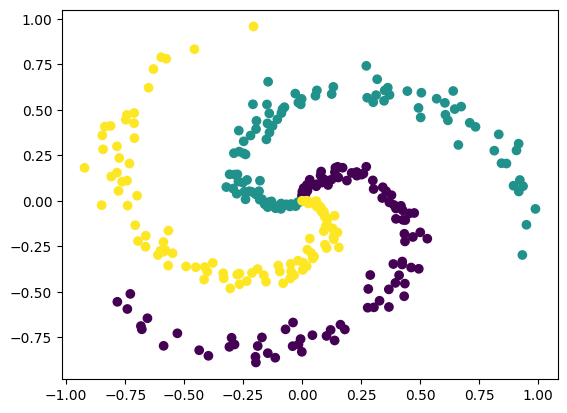

In [3]:
import sys
sys.path.append('..')
from dataset import spiral
import matplotlib.pyplot as plt

x, t = spiral.load_data()
print(x.shape)
print(t.shape)

plt.scatter(x[:, 0], x[:, 1], c=t.argmax(axis=1), cmap='viridis')
plt.show()

In [4]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import Affine, Sigmoid, SoftmaxWithLoss

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size
        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)

        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]
        self.loss_layer = SoftmaxWithLoss()

        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def forward(self, x, t):
        score = self.predict(x)
        loss = self.loss_layer.forward(score, t)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

In [5]:
import sys
sys.path.append('..')
from common.optimizer import SGD

max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iters in range(max_iters):
        batch_x = x[iters * batch_size:(iters + 1) * batch_size]
        batch_t = t[iters * batch_size:(iters + 1) * batch_size]

        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)

        total_loss += loss
        loss_count += 1

        if (iters + 1) % 10 == 0:
            avg_loss = total_loss / loss_count
            print('| epoch %d | iter %d / %d | loss %.2f' % (epoch + 1, iters + 1, max_iters, avg_loss))
            loss_list.append(avg_loss)
            total_loss, loss_count = 0, 0


| epoch 1 | iter 10 / 10 | loss 1.13
| epoch 2 | iter 10 / 10 | loss 1.13
| epoch 3 | iter 10 / 10 | loss 1.12
| epoch 4 | iter 10 / 10 | loss 1.12
| epoch 5 | iter 10 / 10 | loss 1.11
| epoch 6 | iter 10 / 10 | loss 1.14
| epoch 7 | iter 10 / 10 | loss 1.16
| epoch 8 | iter 10 / 10 | loss 1.11
| epoch 9 | iter 10 / 10 | loss 1.12
| epoch 10 | iter 10 / 10 | loss 1.13
| epoch 11 | iter 10 / 10 | loss 1.12
| epoch 12 | iter 10 / 10 | loss 1.11
| epoch 13 | iter 10 / 10 | loss 1.09
| epoch 14 | iter 10 / 10 | loss 1.08
| epoch 15 | iter 10 / 10 | loss 1.04
| epoch 16 | iter 10 / 10 | loss 1.03
| epoch 17 | iter 10 / 10 | loss 0.96
| epoch 18 | iter 10 / 10 | loss 0.92
| epoch 19 | iter 10 / 10 | loss 0.92
| epoch 20 | iter 10 / 10 | loss 0.87
| epoch 21 | iter 10 / 10 | loss 0.85
| epoch 22 | iter 10 / 10 | loss 0.82
| epoch 23 | iter 10 / 10 | loss 0.79
| epoch 24 | iter 10 / 10 | loss 0.78
| epoch 25 | iter 10 / 10 | loss 0.82
| epoch 26 | iter 10 / 10 | loss 0.78
| epoch 27 | iter 10 

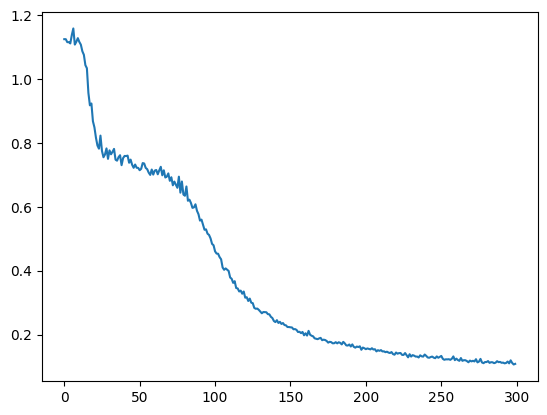

In [6]:
plt.plot(np.arange(len(loss_list)), loss_list, label='train')

| epoch 1 |  iter 1 / 10 | time 0[s] | loss 1.10
| epoch 2 |  iter 1 / 10 | time 0[s] | loss 1.12
| epoch 3 |  iter 1 / 10 | time 0[s] | loss 1.13
| epoch 4 |  iter 1 / 10 | time 0[s] | loss 1.12
| epoch 5 |  iter 1 / 10 | time 0[s] | loss 1.12
| epoch 6 |  iter 1 / 10 | time 0[s] | loss 1.10
| epoch 7 |  iter 1 / 10 | time 0[s] | loss 1.14
| epoch 8 |  iter 1 / 10 | time 0[s] | loss 1.16
| epoch 9 |  iter 1 / 10 | time 0[s] | loss 1.11
| epoch 10 |  iter 1 / 10 | time 0[s] | loss 1.12
| epoch 11 |  iter 1 / 10 | time 0[s] | loss 1.12
| epoch 12 |  iter 1 / 10 | time 0[s] | loss 1.12
| epoch 13 |  iter 1 / 10 | time 0[s] | loss 1.10
| epoch 14 |  iter 1 / 10 | time 0[s] | loss 1.09
| epoch 15 |  iter 1 / 10 | time 0[s] | loss 1.08
| epoch 16 |  iter 1 / 10 | time 0[s] | loss 1.04
| epoch 17 |  iter 1 / 10 | time 0[s] | loss 1.03
| epoch 18 |  iter 1 / 10 | time 0[s] | loss 0.94
| epoch 19 |  iter 1 / 10 | time 0[s] | loss 0.92
| epoch 20 |  iter 1 / 10 | time 0[s] | loss 0.92
| epoch 2

| epoch 28 |  iter 1 / 10 | time 0[s] | loss 0.76
| epoch 29 |  iter 1 / 10 | time 0[s] | loss 0.77
| epoch 30 |  iter 1 / 10 | time 0[s] | loss 0.76
| epoch 31 |  iter 1 / 10 | time 0[s] | loss 0.77
| epoch 32 |  iter 1 / 10 | time 0[s] | loss 0.75
| epoch 33 |  iter 1 / 10 | time 0[s] | loss 0.78
| epoch 34 |  iter 1 / 10 | time 0[s] | loss 0.77
| epoch 35 |  iter 1 / 10 | time 0[s] | loss 0.78
| epoch 36 |  iter 1 / 10 | time 0[s] | loss 0.74
| epoch 37 |  iter 1 / 10 | time 0[s] | loss 0.75
| epoch 38 |  iter 1 / 10 | time 0[s] | loss 0.77
| epoch 39 |  iter 1 / 10 | time 0[s] | loss 0.75
| epoch 40 |  iter 1 / 10 | time 0[s] | loss 0.73
| epoch 41 |  iter 1 / 10 | time 0[s] | loss 0.75
| epoch 42 |  iter 1 / 10 | time 0[s] | loss 0.76
| epoch 43 |  iter 1 / 10 | time 0[s] | loss 0.79
| epoch 44 |  iter 1 / 10 | time 0[s] | loss 0.74
| epoch 45 |  iter 1 / 10 | time 0[s] | loss 0.75
| epoch 46 |  iter 1 / 10 | time 0[s] | loss 0.73
| epoch 47 |  iter 1 / 10 | time 0[s] | loss 0.73


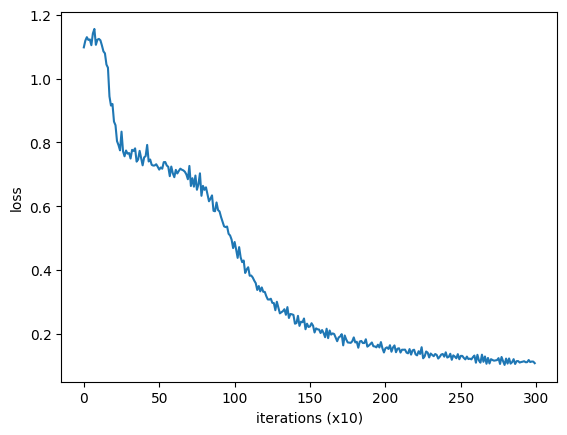

In [7]:
import sys
sys.path.append('..')
from common.optimizer import SGD
from common.trainer import Trainer
from dataset import spiral

max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

trainer = Trainer(model, optimizer)
trainer.fit(x, t, max_epoch, batch_size, eval_interval=10)
trainer.plot()

